**Name:** Manu Sharan Kumar  
**Roll No:** ACE080BCT037  

---

# Lab 9: Introduction to PyTorch III
## Task 2 — Convolutional Neural Network (Custom CNN with `nn.Module`)

This notebook builds a **custom Convolutional Neural Network** for the MNIST digit dataset using `torch.nn.Module`, and explains the `nn.Conv2d(1, 6, 5, 1)` layer and the output-size formula shown on the whiteboard:

$$\text{Output Size} = \frac{W-K}{S} + 1$$

## 1. What is a Convolutional Neural Network?

A CNN is a deep learning architecture designed specifically for grid-like data such as images. Instead of connecting every input pixel to every neuron (like a plain fully-connected network), a CNN slides small learnable filters (**kernels**) across the image to detect local patterns — edges, corners, curves — and builds up more complex features layer by layer.

CNNs are preferred over plain feedforward networks for images because:
- **Parameter efficiency** — one small kernel is reused across the whole image instead of learning a separate weight for every pixel.
- **Spatial awareness** — nearby pixels are processed together, preserving spatial structure that a flattened fully-connected input would destroy.
- **Translation invariance** — a feature (e.g. an edge) is detected regardless of where it appears in the image.

## 2. Understanding `nn.Conv2d` — what does `(1, 6, 5, 1)` mean?

On the board, the layer is written as:

```
(1, 6, 5, 1)
 ↑  ↑  ↑  ↑
 |  |  |  stride
 |  |  kernel_size
 |  out_channels
 in_channels
```

In PyTorch this is:

```python
nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
```

| Parameter | Value | Meaning |
|---|---|---|
| `in_channels` | 1 | Number of channels in the input (1 = grayscale, 3 = RGB) |
| `out_channels` | 6 | Number of filters/kernels this layer learns → produces 6 feature maps |
| `kernel_size` | 5 | Each filter is a 5×5 sliding window |
| `stride` | 1 | The filter moves 1 pixel at a time across the image |

Each of the 6 output filters is applied independently across the whole input image, so a single `Conv2d(1, 6, 5, 1)` layer produces **6 separate 2D feature maps**, each highlighting a different learned pattern.

## 3. Output size formula

After a convolution, the spatial size (height/width) of the feature map shrinks (unless padding is used). The board gives the formula:

$$\text{Output Size} = \frac{W-K}{S} + 1$$

Where:
- **W** = input width/height (assuming a square input)
- **K** = kernel size
- **S** = stride

### Board example: `(32 - 5)/1 + 1`

If the input image is **32×32** and we apply a `Conv2d(1, 6, kernel_size=5, stride=1)`:

$$\frac{32-5}{1}+1 = \frac{27}{1}+1 = 28$$

So the output feature map shrinks from 32×32 down to **28×28** (but now has **6 channels** instead of 1, because `out_channels=6`).

This 32→28 sizing is the classic **LeNet-5** architecture design (Yann LeCun's original CNN for digit recognition). MNIST images are natively 28×28, so to reproduce this exact LeNet-5 sizing we **pad** each MNIST image with a 2-pixel border on every side, turning it into 32×32, before it enters the network.

In [ ]:
# Verify the board's formula in code
W, K, S = 32, 5, 1
output_size = (W - K)//S + 1
print(f"({W}-{K})/{S} + 1 = {output_size}")   # -> 28, matches the board

## 4. Setup

Import PyTorch and supporting libraries. We also select the device (CPU/GPU) as in Task 1, since a real CNN trains much faster on GPU.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 5. Load the MNIST dataset

We use `torchvision.datasets.MNIST`, and pad every image from 28×28 to **32×32** with `transforms.Pad(2)` so it matches the board's `(32-5)/1+1 = 28` example exactly.

- **Training set**: split into a train/validation split, similar to the custom-NN pattern from Part 1 of the appendix.
- **Test set**: kept separate, used only for final evaluation.

In [2]:
transform = transforms.Compose([
    transforms.Pad(2),        # 28x28 -> 32x32, to match the board's (32-5)/1+1 example
    transforms.ToTensor()
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

torch.manual_seed(42)  # make the train/val split reproducible
train_set, val_set = torch.utils.data.random_split(train_data, [50000, 10000])

test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=1000, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=1000, shuffle=False)

print("Train samples:", len(train_set))
print("Validation samples:", len(val_set))
print("Test samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.31MB/s]

Train samples: 50000
Validation samples: 10000
Test samples: 10000


Batch shape: torch.Size([64, 1, 32, 32])
Single image shape: torch.Size([1, 32, 32])


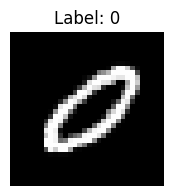

In [3]:
# Confirm the padded image shape is 32x32
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)   # [batch_size, channels, height, width]
print("Single image shape:", images[0].shape)

plt.figure(figsize=(2, 2))
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off");

## 6. Walking through the layer shapes step by step

Before writing the full model class, let's trace the tensor shape through each layer manually — the same way you'd verify it on the board — to confirm the formula holds at every stage.

**Architecture plan (LeNet-5 style):**
1. `Conv2d(1, 6, 5, 1)` → 32×32 → 28×28
2. `MaxPool2d(2, 2)` → 28×28 → 14×14
3. `Conv2d(6, 16, 5, 1)` → 14×14 → 10×10
4. `MaxPool2d(2, 2)` → 10×10 → 5×5
5. Flatten → 16×5×5 = 400
6. Fully connected layers → 120 → 84 → 10 (digit classes)

In [4]:
conv1 = nn.Conv2d(1, 6, 5, 1).to(device)   # (in_channels, out_channels, kernel_size, stride)
conv2 = nn.Conv2d(6, 16, 5, 1).to(device)

x = images[0].view(1, 1, 32, 32).to(device)
print("Input:", x.shape)

x = F.relu(conv1(x))
print("After conv1 (1,6,5,1):", x.shape)     # expect [1, 6, 28, 28]

x = F.max_pool2d(x, 2, 2)
print("After pool1:", x.shape)               # expect [1, 6, 14, 14]

x = F.relu(conv2(x))
print("After conv2 (6,16,5,1):", x.shape)    # expect [1, 16, 10, 10]

x = F.max_pool2d(x, 2, 2)
print("After pool2:", x.shape)               # expect [1, 16, 5, 5]

x = x.view(-1, 16*5*5)
print("Flattened:", x.shape)                 # expect [1, 400]

Input: torch.Size([1, 1, 32, 32])
After conv1 (1,6,5,1): torch.Size([1, 6, 28, 28])
After pool1: torch.Size([1, 6, 14, 14])
After conv2 (6,16,5,1): torch.Size([1, 16, 10, 10])
After pool2: torch.Size([1, 16, 5, 5])
Flattened: torch.Size([1, 400])


## 7. Building the custom CNN with `nn.Module`

Now we wrap the layer sequence above into a reusable `nn.Module` class — this is what "custom NN" on the board refers to: a hand-written architecture rather than using a pre-built model.

In [5]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5, 1)     # (1,6,5,1) from the board
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)          # 10 output classes (digits 0-9)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 16*5*5)                  # flatten
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

torch.manual_seed(42)
model = CustomCNN().to(device)
print(model)

CustomCNN(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [6]:
def count_parameters(model):
    total = 0
    for p in model.parameters():
        if p.requires_grad:
            total += p.numel()
    return total

print("Total trainable parameters:", count_parameters(model))

Total trainable parameters: 61706


## 8. Loss function and optimizer

- **Loss**: `CrossEntropyLoss` — standard choice for multi-class classification (10 digit classes).
- **Optimizer**: `Adam` — adapts the learning rate per parameter, generally converges faster than plain SGD for CNNs.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 9. Training loop

For each epoch we loop over training batches, compute predictions, calculate loss, backpropagate, and update weights — the same pattern as Task 1, applied here to image batches instead of toy vectors.

In [ ]:
import time

epochs = 5
train_losses, val_losses = [], []
train_acc, val_acc = [], []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    trn_correct = 0
    trn_loss_sum = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        predicted = torch.argmax(y_pred, dim=1)
        trn_correct += (predicted == y_batch).sum().item()
        # accumulate loss weighted by batch size so the epoch average is correct
        # even for the smaller final batch
        trn_loss_sum += loss.item() * X_batch.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_losses.append(trn_loss_sum / len(train_set))
    train_acc.append(trn_correct / len(train_set))

    # Validation
    model.eval()
    val_correct = 0
    val_loss_sum = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_pred = model(X_val)
            vloss = criterion(y_pred, y_val)
            predicted = torch.argmax(y_pred, dim=1)
            val_correct += (predicted == y_val).sum().item()
            val_loss_sum += vloss.item() * X_val.size(0)

    val_losses.append(val_loss_sum / len(val_set))
    val_acc.append(val_correct / len(val_set))

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} "
          f"| Train Acc: {train_acc[-1]*100:.2f}% | Val Loss: {val_losses[-1]:.4f} "
          f"| Val Acc: {val_acc[-1]*100:.2f}%")

print(f"\nTotal training time: {time.time()-start_time:.2f} sec")

**Bug fix (originally logged only the last batch's loss/accuracy each epoch):** the previous version appended `loss.item()` straight from the final mini-batch of each epoch to `train_losses`/`val_losses`, so the reported numbers were noisy and not representative of the whole epoch. The corrected version accumulates `loss.item() * batch_size` across every batch and divides by the dataset size, giving the true epoch-average training/validation loss. Re-run this cell (a GPU runtime with internet access to download MNIST is required) to regenerate the training curve with the corrected numbers.

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per epoch')
plt.legend();

## 10. Evaluating on the test set

We switch to `model.eval()` and wrap inference in `torch.no_grad()` so no gradient graph is built — this is the same inference pattern from Task 1, applied to real image data.

In [10]:
model.eval()
correct = 0
with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        y_val = model(X_test)
        predicted = torch.argmax(y_val, dim=1)
        correct += (predicted == y_test).sum().item()

print(f"Test accuracy: {correct}/{len(test_data)} = {correct*100/len(test_data):.3f}%")

Test accuracy: 9876/10000 = 98.760%


## 11. Single image test

Finally, run the model on one specific test image and visually confirm the prediction, and check which device the output tensor lives on — tying back to Task 1's question.

Predicted digit: 9
Output tensor is on device: cpu


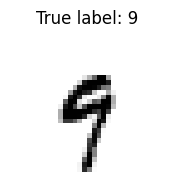

In [11]:
idx = 2019
sample_image, sample_label = test_data[idx]

plt.figure(figsize=(2, 2))
plt.imshow(sample_image.squeeze(), cmap="gray_r")
plt.title(f"True label: {sample_label}")
plt.axis("off");

model.eval()
with torch.no_grad():
    output = model(sample_image.view(1, 1, 32, 32).to(device))
    pred = output.argmax().item()

print("Predicted digit:", pred)
print("Output tensor is on device:", output.device)

## 12. Summary

| Board notation | Meaning |
|---|---|
| `(1, 6, 5, 1)` | `Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)` |
| `(32-5)/1 + 1` | Output size formula: `(W-K)/S + 1` → 32×32 input shrinks to 28×28 after this conv |
| MNIST dataset | Loaded via `torchvision.datasets.MNIST`, padded to 32×32 to match the board's example |
| Custom NN | `class CustomCNN(nn.Module)` with 2 conv layers + 2 pooling layers + 3 fully connected layers |
| `nn.Module` | Base class every custom PyTorch model inherits from; tracks parameters, gradients, and device placement automatically |
| `Conv2D` | `nn.Conv2d` — the convolutional layer that slides learnable kernels over the input |

**Key takeaways:**
1. Each convolution shrinks the spatial size according to `(W-K)/S + 1`, while the number of channels grows to match `out_channels`.
2. Pooling further halves the spatial size without adding parameters — it just downsamples.
3. The final flattened vector feeds into fully connected layers that produce class scores (logits) for the 10 digits.